In [99]:
import operator
from typing import Annotated, List, TypedDict, Literal
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage, AnyMessage, AIMessage, ToolMessage
from langgraph.graph import StateGraph, END, START
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_classic.tools.retriever import create_retriever_tool
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver


In [82]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

In [140]:
class SelfCorr(TypedDict):
    messages : Annotated[list[AnyMessage], add_messages]
    result : str = ""
    attempt : int = 0
    saran: str = "tidak ada saran"
    bef_result: Annotated[list[str], operator.add] 
    saran_list: Annotated[list[str], operator.add]
    

In [ ]:
def make_retriever_tool_from_text(file_path, tool_name, desc):
    loader = PyMuPDFLoader(file_path=file_path)
    docs = loader.load()
    
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=80)
    chunks = text_splitter.split_documents(docs)
    
    vectorstore = FAISS.from_documents(chunks, OpenAIEmbeddings())
    retriever = vectorstore.as_retriever()
    
    def tool_retriever():
        retriever_tool = create_retriever_tool(
            retriever,
            tool_name,
            desc
        )
    
        return retriever_tool
    
    retriever_tool = tool_retriever()
    return retriever_tool

In [85]:
nilai_farhan_tool = make_retriever_tool_from_text(
    "pdf/farhan.pdf",
    "SikadFarhan",
    "Mencari informasi nilai untuk mahasiswa farhan dan IPK farhan atau hasil akhir perkuliahan farhan"
)

nilai_ratu_tool = make_retriever_tool_from_text(
    "pdf/ratu.pdf",
    "SikadRatu",
    "Mencari informasi nilai untuk mahasiswa Ratu dan IPK Ratu atau hasil akhir perkuliahan Ratu"
)

tools = [nilai_farhan_tool, nilai_ratu_tool]

In [86]:
tools
model = ChatGroq(model_name="openai/gpt-oss-120b",  streaming=True)

In [87]:
llm_with_tools = model.bind_tools(tools)

In [214]:
def generation(state: SelfCorr) -> SelfCorr:
    # Ambil saran jika ada
    saran = state.get("saran", "tidak ada saran")
    
    
    
    # Buat instruksi dalam SystemMessage
    system_instruction = f"""Kamu adalah agent cerdas. Gunakan tools yang tersedia untuk menjawab pertanyaan user.
    
    CATATAN / SARAN PERBAIKAN DARI LANGKAH SEBELUMNYA:
    {saran}
    """
    
    # Gabungkan instruksi dengan riwayat chat yang ada di state
    # Ini PENTING agar LLM ingat dia sedang memanggil tool apa sebelumnya
    messages = [SystemMessage(content=system_instruction)] + state["messages"]
    
    # Invoke model
    response = llm_with_tools.invoke(messages)
    
    
    # Kembalikan response sebagai list (untuk di-append ke messages)
    # dan juga update result (hanya jika ada konten teks)
    return {
        "messages": [response], 
        "result": response.content, 

        "bef_result" : [response.content]
    }

In [215]:
def result_correction(state:SelfCorr) -> SelfCorr:
    question = state["messages"][0].content
    result = state["result"]
    attempt = state.get("attempt", 0)
    
    
    if attempt < 2:
        fake_saran = f"SARAN: MASUKKAN WALI DOSEN NYA"
        print(f"--- TESTING: Memaksa Loop karena attempt {attempt} < 3 ---")
        
        return {
            "saran": fake_saran,
            "saran_list": [fake_saran],
            "attempt": attempt + 1 # Increment di sini sesuai request Anda
        }
    # ============================================
    
    
    prompt = f"""
        kamu adalah seorang agent yang mengoreksi hasil jawaban dari agent sebelumnya, kamu harus mengecek pertanyaan dan result untuk kesesuain agar hasil maksimal,
        
        jika sesuai, berikan output ke user seperti "Jawaban sudah dicek dengan teliti dan sesuai" dan jika tidak sesuai lakukan sebaliknya dan jawaban akan dihasilkan kembali oleh agent sebelumnya, 
        berikan saran agar agent sebelumnya tau apa yang harus diperbaiki 
        
        
        
        jika tidak ada saran, keluarkan output yang sudah diberikan oleh agent tersebut dan kasih tahu agent selanjutnya agar dilanjutkan jika ada saran, kasih tahu bahwa jawaban harus dibentuk ulang
        
        
        pertanyaan:
        {question}
        
        result dari agent sebelumnya:
        {result}
    """
    
    
    
    response= llm_with_tools.invoke(prompt)
    print(response)
    print("=" * 50)
    return {"saran" : response.content,
            "saran_list" : [response.content],
             "attempt": attempt + 1,
            }

In [ ]:
def final_check(state:SelfCorr) -> Literal["tidak", "generation" ]:
    saran = state["saran"]
    result = state["result"]
    
    
    prompt = f"""
        kamu harus mengecek jawaban dari agent correction, agent tersebut akan memberikan kamu sebuah jawsaban yang dimana kalau misalkan dia sarannya tidak ada maka kamu harus meneruskan output yang sudah ada
        
        output dari agent correction:
        {saran}
        
        jawaban kamu harus HANYA (lowercase):
        
        jika ada saran keluarkan = ya
        jika tidak ada keluarkan = tidak
        
    """
    
    response_msg = llm_with_tools.invoke(prompt)
    
    # AMBIL CONTENT-NYA & BERSIHKAN
    answer = response_msg.content.lower().strip()
    
    # Cek apakah mengandung kata "ya"
    if "ya" in answer:
        return "generation"
    else:
        return "tidak"

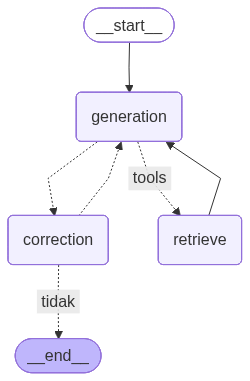

In [219]:
workflow = StateGraph(SelfCorr)
retrieve = ToolNode(tools)

def route_after_generation(state: SelfCorr):
    last_message = state["messages"][-1]
    
    # Jika ada tool_calls, arahkan ke node 'tools'
    if last_message.tool_calls:
        return "tools"
    
    # Jika tidak ada tool_calls (berarti teks jawaban), arahkan ke 'correction'
    return "correction"

workflow.add_node("generation", generation)
workflow.add_node("correction", result_correction)
workflow.add_node("retrieve", retrieve)

workflow.add_edge(START, "generation")
workflow.add_conditional_edges(
    "generation",
    route_after_generation,
    {
        "tools": "retrieve",
        "correction": "correction"
    }
)


workflow.add_edge("retrieve", "generation")

workflow.add_conditional_edges(
    "correction",
    final_check,
    {
        "generation" : "generation",
        "tidak" : END
    }
)

graph = workflow.compile()
graph


In [220]:
state = {
    "messages": [HumanMessage(content="Bisa berikan nilai ratu dan farhan dan lakukan perbandingan antara kedua itu dan menurut kamu siapa yang paling memiliki sisi menarik dan memiliki kesempatan untuk magang?")],
    "saran": "tidak ada saran", # Inisialisasi manual
    "attempt": 0,               # Inisialisasi manual
    "result": "",
    "bef_result": [], # WAJIB DI-INISIALISASI
    "saran_list": []  # WAJIB DI-INISIALISASI
}

response = graph.invoke(state)


--- TESTING: Memaksa Loop karena attempt 0 < 3 ---
--- TESTING: Memaksa Loop karena attempt 1 < 3 ---
content='Jawaban sudah dicek dengan teliti dan sesuai.' additional_kwargs={'reasoning_content': 'We need to evaluate if the result matches the question. Question: "Bisa berikan nilai ratu dan farhan dan lakukan perbandingan antara kedua itu dan menurut kamu siapa yang paling memiliki sisi menarik dan memiliki kesempatan untuk magang?" The result provides table of IPK, SKS, grades, comparison, conclusion. That matches. Need to check if any missing info: maybe need specific numeric grades? They gave approximate grades. Probably sufficient. So answer is appropriate. Provide output: "Jawaban sudah dicek dengan teliti dan sesuai".'} response_metadata={'finish_reason': 'stop', 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_4727af4560', 'service_tier': 'on_demand', 'model_provider': 'groq'} id='lc_run--019c08a9-ea47-7632-937b-59ba23f3dd4c' usage_metadata={'input_tokens': 1472,

In [226]:
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Bisa berikan nilai ratu dan farhan dan lakukan perbandingan antara kedua itu dan menurut kamu siapa yang paling memiliki sisi menarik dan memiliki kesempatan untuk magang?
================================== Ai Message ==================================
Tool Calls:
  SikadRatu (fc_77e9c0b8-e095-43de-91a7-3d0350690d06)
 Call ID: fc_77e9c0b8-e095-43de-91a7-3d0350690d06
  Args:
    query: nilai ratu IPK
================================= Tool Message =================================
Name: SikadRatu

** AKTIVITAS KULIAH MAHASISWA **
Semester
:
GANJIL 2025/2026
Tanggal : 27-01-2026
Program Studi :
INFORMATIKA
Jam : 14:02
N.I.M
:
15-2024-151 RATU QOLBU MAZIAH          Telpon:  62-812-2429-4989           E-mail : qratu95@gmail.com
Form : AKT298C
Batas Studi
:
GENAP 2030/2031          Jumlah Cuti: 0          IPK: 3.08          SKS Peroleh:  46
Hal : 1
Dosen Wali
:
11565 YUSUP MIFTAHUDDIN
No
Kode
Matakuliah
SKS
Kel

In [231]:
print(response["saran_list"])

['SARAN: MASUKKAN WALI DOSEN NYA', 'SARAN: MASUKKAN WALI DOSEN NYA', 'Jawaban sudah dicek dengan teliti dan sesuai.']


In [232]:
response["attempt"]

3

In [237]:
for i, msg in enumerate(response["bef_result"]):
    print("Messsage ke", {i + 1})
    print(msg)
    print("=" * 100)

Messsage ke {1}

Messsage ke {2}

Messsage ke {3}
**Ringkasan Nilai Akademik**

| Mahasiswa | IPK | SKS yang Diperoleh | Nilai‑nilai Utama (contoh) |
|-----------|-----|-------------------|----------------------------|
| **Ratu Qolbu Maziah** | **3,08** | 46 | • Rekayasa Perangkat Lunak: **AB** (nilai rata‑rata ≈ 78) <br>• Pemrograman Dasar: **AB** (nilai rata‑rata ≈ 73) <br>• Interaksi Manusia‑Komputer: **AB** (nilai rata‑rata ≈ 78) <br>• Pemrograman Basis Data: **AB** (nilai rata‑rata ≈ 78) |
| **Farhan Kamil Hermansyah** | **3,97** | 50 | • Rekayasa Perangkat Lunak: **A** (nilai rata‑rata ≈ 92) <br>• Pemrograman Dasar: **A** (nilai rata‑rata ≈ 90) <br>• Bahasa Inggris I: **A** (nilai rata‑rata ≈ 92) <br>• Interaksi Manusia‑Komputer: **A** (nilai rata‑rata ≈ 82) <br>• Pemrograman Basis Data: **A** (nilai rata‑rata ≈ 92) <br>• Sistem Operasi: **A** (nilai rata‑rata ≈ 89) |

**Perbandingan**

| Aspek | Ratu | Farhan |
|-------|------|--------|
| **IPK** | 3,08 (di bawah rata‑rata jurus

In [230]:
response["saran_list"]

['SARAN: MASUKKAN WALI DOSEN NYA',
 'SARAN: MASUKKAN WALI DOSEN NYA',
 'Jawaban sudah dicek dengan teliti dan sesuai.']